# Derivatives in 2D

We will revise how to compute derivatives in 2D. In particular, we will compute the:

- Gradient of scalar fields


- Curl of vector fields


- Divergence of vector fields


To illustrate the process, we will use data from the ($50\times 50$ pixels) turbulence simulation that we studied earlier, plus one more simulatin ran on a finer grid (i.e. at higher numerical resolution, $200\times 200$ pixels)).

In [2]:
import pyvista as pv
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

## Get CGS normalisation units from units.out:

In [3]:
units_data = pd.read_csv("/home/prostofsound/jnotebooks/computational-physics-1/Notes/data/simulation_data/TURB_DRIVE_SUP_hr/units.out")

#units_data = pd.read_csv("./TURB_DRIVE_SUP_hr/units.out")

In [4]:
print(units_data)

  variable  normalisation   units
0    rho_0   1.660000e-24  g/cm^3
1      v_0   1.000000e+06    cm/s
2      L_0   3.086000e+18      cm
3    c_iso   1.000000e+06    cm/s


In [6]:
#Normalisation values
rho_00   = np.array(units_data.loc[units_data["variable"] == "rho_0"]["normalisation"])
vel_00   = np.array(units_data.loc[units_data["variable"] == "v_0"]["normalisation"])
len_00   = np.array(units_data.loc[units_data["variable"] == "L_0"]["normalisation"])
c_iso   = np.array(units_data.loc[units_data["variable"] == "c_iso"]["normalisation"])

#Derived normalisation values
tim_00 = (len_00/vel_00)
bfi_00 = (np.sqrt(4*np.pi*rho_00*vel_00**2))

## Read meshes:

In [9]:
mesh = pv.read("/home/prostofsound/jnotebooks/computational-physics-1/Notes/data/simulation_data/TURB_DRIVE_SUP/data.0010.vtk")
mesh_hr = pv.read("/home/prostofsound/jnotebooks/computational-physics-1/Notes/data/simulation_data/TURB_DRIVE_SUP_hr/data.0010.vtk")

In [10]:
print(mesh_hr)

RectilinearGrid (0x7b9defdd2e60)
  N Cells:      40000
  N Points:     40401
  X Bounds:     -2.000e+00, 2.000e+00
  Y Bounds:     -2.000e+00, 2.000e+00
  Z Bounds:     0.000e+00, 0.000e+00
  Dimensions:   201, 201, 1
  N Arrays:     5


## Read arrays:

#### Low-resolution:

In [11]:
# Getting the data arrays
rho = pv.get_array(mesh, "rho", preference = 'cell') #density in code units
vx1 = pv.get_array(mesh, "vx1", preference = 'cell') #vx in code units
vx2 = pv.get_array(mesh, "vx2", preference = 'cell') #vy in code units

Bx1 = pv.get_array(mesh, "Bx1", preference = 'cell') #Bx in code units
Bx2 = pv.get_array(mesh, "Bx2", preference = 'cell') #By in code units    

#### High-resolution:

In [12]:
# Getting the data arrays
rho_hr = pv.get_array(mesh_hr, "rho", preference = 'cell') #density in code units
vx1_hr = pv.get_array(mesh_hr, "vx1", preference = 'cell') #vx in code units
vx2_hr = pv.get_array(mesh_hr, "vx2", preference = 'cell') #vy in code units

Bx1_hr = pv.get_array(mesh_hr, "Bx1", preference = 'cell') #Bx in code units
Bx2_hr = pv.get_array(mesh_hr, "Bx2", preference = 'cell') #By in code units    

### 2D conversion:

#### Low-resolution:

In [13]:
# Convert the arrays to 2D
rho_2D = rho.reshape(mesh.dimensions[0] - 1, mesh.dimensions[1] - 1)
vx1_2D = vx1.reshape(mesh.dimensions[0] - 1, mesh.dimensions[1] - 1)
vx2_2D = vx2.reshape(mesh.dimensions[0] - 1, mesh.dimensions[1] - 1)
Bx1_2D = Bx1.reshape(mesh.dimensions[0] - 1, mesh.dimensions[1] - 1)
Bx2_2D = Bx2.reshape(mesh.dimensions[0] - 1, mesh.dimensions[1] - 1)

# Convert arrays to CGS units
rho_cgs2D = rho_2D*rho_00
vx1_cgs2D = vx1_2D*vel_00
vx2_cgs2D = vx2_2D*vel_00
Bx1_cgs2D = Bx1_2D*bfi_00
Bx2_cgs2D = Bx2_2D*bfi_00

#### High-resolution:

In [14]:
# Convert the arrays to 2D
rho_2D_hr = rho_hr.reshape(mesh_hr.dimensions[0] - 1, mesh_hr.dimensions[1] - 1)
vx1_2D_hr = vx1_hr.reshape(mesh_hr.dimensions[0] - 1, mesh_hr.dimensions[1] - 1)
vx2_2D_hr = vx2_hr.reshape(mesh_hr.dimensions[0] - 1, mesh_hr.dimensions[1] - 1)
Bx1_2D_hr = Bx1_hr.reshape(mesh_hr.dimensions[0] - 1, mesh_hr.dimensions[1] - 1)
Bx2_2D_hr = Bx2_hr.reshape(mesh_hr.dimensions[0] - 1, mesh_hr.dimensions[1] - 1)

# Convert arrays to CGS units
rho_cgs2D_hr = rho_2D_hr*rho_00
vx1_cgs2D_hr = vx1_2D_hr*vel_00
vx2_cgs2D_hr = vx2_2D_hr*vel_00
Bx1_cgs2D_hr = Bx1_2D_hr*bfi_00
Bx2_cgs2D_hr = Bx2_2D_hr*bfi_00

## Create grids for plotting:

#### Low-resolution:

In [15]:
x = np.linspace(mesh.bounds[0]*len_00, mesh.bounds[1]*len_00, mesh.dimensions[0] - 1)
y = np.linspace(mesh.bounds[2]*len_00, mesh.bounds[3]*len_00, mesh.dimensions[1] - 1)

X, Y = np.meshgrid(x, y)

#### High-resolution:

In [16]:
x_hr = np.linspace(mesh_hr.bounds[0]*len_00, mesh_hr.bounds[1]*len_00, mesh_hr.dimensions[0] - 1)
y_hr = np.linspace(mesh_hr.bounds[2]*len_00, mesh_hr.bounds[3]*len_00, mesh_hr.dimensions[1] - 1)

X_hr, Y_hr = np.meshgrid(x_hr, y_hr)

In [13]:
#xx_hr = np.linspace(mesh_hr.bounds[0], mesh_hr.bounds[1], mesh_hr.dimensions[0] - 1)

In [14]:
print(X_hr.shape)

(200, 200)


## Plotting:

### Low-resolution density:

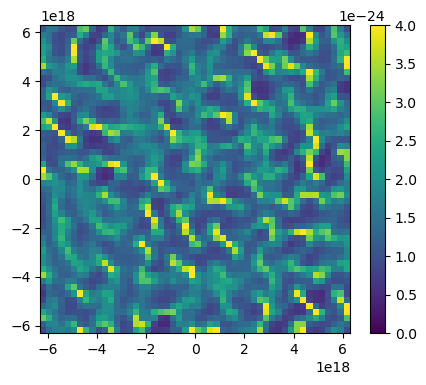

In [17]:
plt.figure(figsize = (5,4))

Z1 = plt.pcolor(X, Y, rho_cgs2D, cmap = 'viridis', shading = 'auto', vmin = 0, vmax = 4.e-24)

CB1 = plt.colorbar(Z1)

plt.show()

Shock waves are good at compressing the gas. We are in spersonic motion. The low-density regions are called rarefraction.

### High-resolution density:

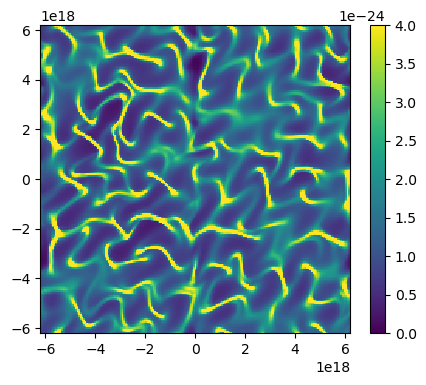

In [18]:
plt.figure(figsize = (5,4))

Z1 = plt.pcolor(X_hr, Y_hr, rho_cgs2D_hr, cmap = 'viridis', shading = 'auto',  vmin = 0, vmax= 4.e-24)

CB1 = plt.colorbar(Z1)

plt.show()

We see very high compressions, due to the shock waves. It is much better to work with high resolution simulations.

# A. Gradient of scalar functions:

## Example:

Calculate the gradient of the density field: $\vec{\nabla} \rho$


## 1. Using numpy.gradient()

https://numpy.org/doc/stable/reference/generated/numpy.gradient.html

### First, we need to define the x-spacing:

In [19]:
dx = np.array(x[1] - x[0], dtype =float)

print(dx) # in CGS units already

print(dx.shape)
print(dx[0])

[2.51918367e+17]
(1,)
2.5191836734693888e+17


### Then, we calculate the gradient:

In [21]:
gradient_rho = np.gradient(rho_cgs2D, dx[0])#the step size must be a number

### which returns a list containing the arrays with the components of the gradient:

$\frac{\partial \rho}{\partial x}$ along $x$.


$\frac{\partial \rho}{\partial y}$ along $y$.

In [22]:
print(type(gradient_rho))

print(gradient_rho)

<class 'list'>
[pyvista_ndarray([[ 1.38925929e-42,  1.17533651e-42,  5.11773084e-43, ...,
                  -2.94783706e-42, -7.80418467e-43,  1.59148054e-42],
                 [ 4.31438299e-42,  2.06024315e-42, -4.35312729e-44, ...,
                  -2.10107812e-42, -1.12038041e-42,  3.71424319e-42],
                 [ 2.24579405e-42,  2.58812611e-43, -5.11263869e-43, ...,
                  -4.86380496e-43, -9.47881546e-44,  8.25663788e-42],
                 ...,
                 [-1.13167445e-42, -7.61801596e-43, -4.46920780e-44, ...,
                   2.99050053e-42, -6.80919144e-43, -1.73171271e-42],
                 [-1.80450390e-42,  4.58507230e-44,  1.13270250e-42, ...,
                   1.56390047e-42, -1.65331801e-42, -2.05381444e-42],
                 [-2.22932951e-42,  2.39463633e-43,  2.05633597e-42, ...,
                  -2.79579849e-43, -1.56737798e-42, -1.95864570e-42]]), pyvista_ndarray([[ 2.30547330e-42,  1.59240746e-42,  5.42276474e-43, ...,
                   7.3

### Get gradient components:

In [23]:
xgradient_rho = gradient_rho[0]

ygradient_rho = gradient_rho[1]

In [24]:
print(xgradient_rho.shape)

(50, 50)


In [25]:
print(ygradient_rho.shape)

(50, 50)


### Then, we check that the units are consistent with the expected dimensions:

$\frac{\partial \rho}{\partial x}$ has units of $[M\,L^{-3}]/[L] = [M\,L^{-4}]$


In [26]:
print(np.max(rho_cgs2D))

6.0330088329315186e-24


In [27]:
print(x[1]-x[0])

[2.51918367e+17]


In [29]:
print(np.max(gradient_rho)) #it does make sense (e-24 - e+17)

1.6037481945787857e-41


It is a very small number. The derivatives may be done before the normalisation, in code units.

### Finally, we make plots of the gradient vector:

### Low-resolution simulation: 

#### Modulus of gradient:

In [30]:
modulus_gradient_rho = np.sqrt(xgradient_rho**2 + ygradient_rho**2)

#### Plot:

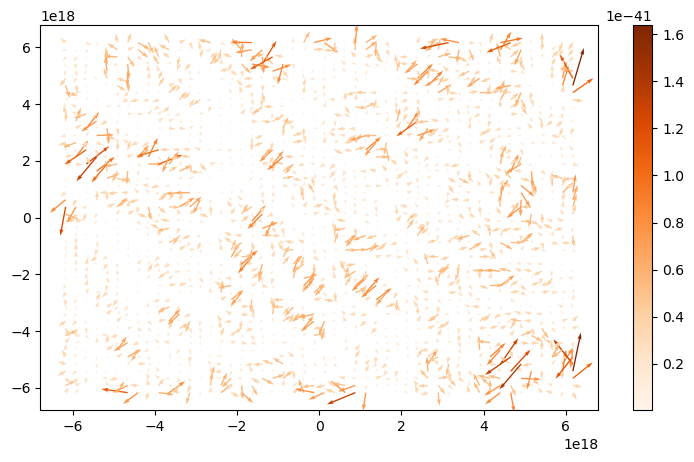

In [35]:
plt.figure(figsize = (9,5))

Z2 = plt.quiver(X, Y, xgradient_rho, ygradient_rho,\
                modulus_gradient_rho, cmap = 'Oranges')#, clim = (0, 1.e-40))

CB2 = plt.colorbar(Z2)

plt.show()

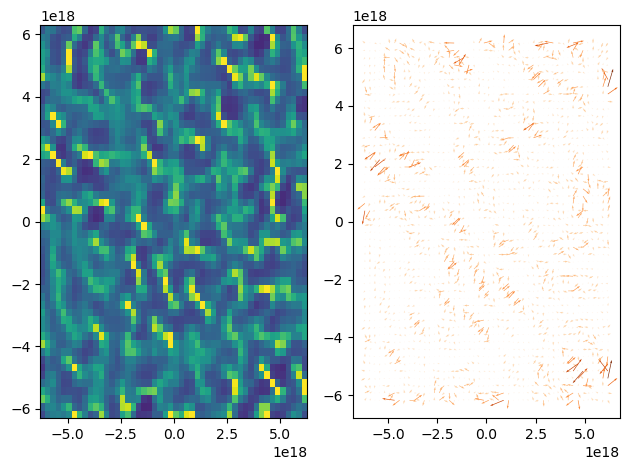

In [34]:
fig, axs = plt.subplots(1,2)

axs[0].pcolor(X, Y, rho_cgs2D, cmap = 'viridis',\
              shading = 'auto', vmin = 0, vmax = 4.e-24)
axs[1].quiver(X, Y, xgradient_rho, ygradient_rho,\
                modulus_gradient_rho, cmap = 'Oranges')

fig.tight_layout()

### High-resolution simulation: 

In [36]:
dx_hr = np.array(x_hr[1] - x_hr[0], dtype=float)

print(dx_hr[0])

6.203015075376845e+16


In [37]:
gradient_rho_hr = np.gradient(rho_cgs2D_hr, dx_hr[0])

In [38]:
xgradient_rho_hr = gradient_rho_hr[0]
ygradient_rho_hr = gradient_rho_hr[1]

In [39]:
modulus_gradient_rho_hr = np.sqrt(xgradient_rho_hr**2 + ygradient_rho_hr**2)

In [40]:
print(np.min(modulus_gradient_rho_hr))
print(np.max(modulus_gradient_rho_hr))

5.510846709523194e-45
1.7556361806717732e-40


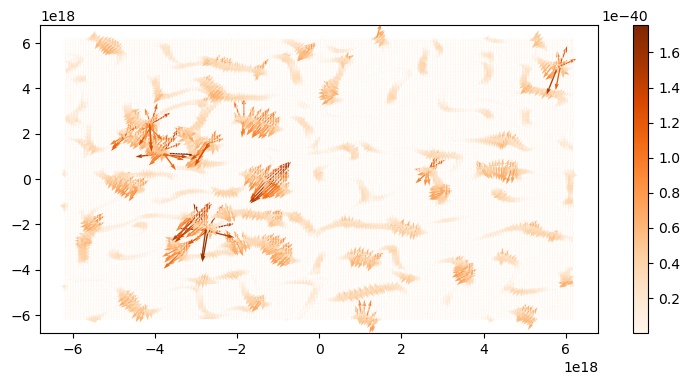

In [42]:
plt.figure(figsize = (9,4))

Z2 = plt.quiver(X_hr, Y_hr, ygradient_rho_hr, xgradient_rho_hr, modulus_gradient_rho_hr, cmap = 'Oranges')#, clim = (0, 1.e-40))

CB2 = plt.colorbar(Z2)

plt.show()

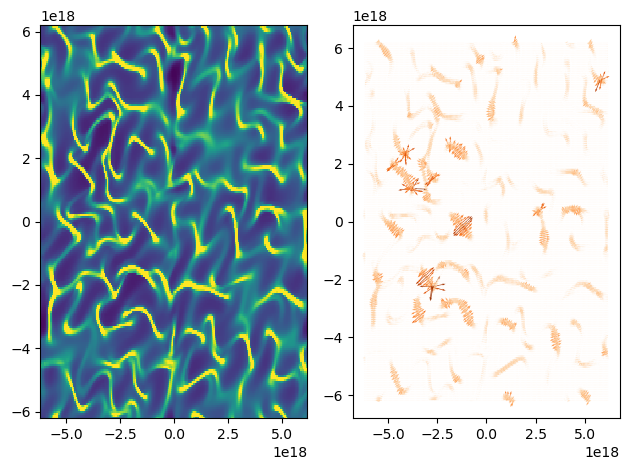

In [43]:
fig, axs = plt.subplots(1,2)

axs[0].pcolor(X_hr, Y_hr, rho_cgs2D_hr, cmap = 'viridis',\
              shading = 'auto', vmin = 0, vmax = 4.e-24)
axs[1].quiver(X_hr, Y_hr, ygradient_rho_hr, xgradient_rho_hr, modulus_gradient_rho_hr, cmap = 'Oranges')

fig.tight_layout()

The high density regions have the bigger gradient magnitude.

#### Plot of the magnitude of the gradients:

Notice how we can see the edges of the filaments.

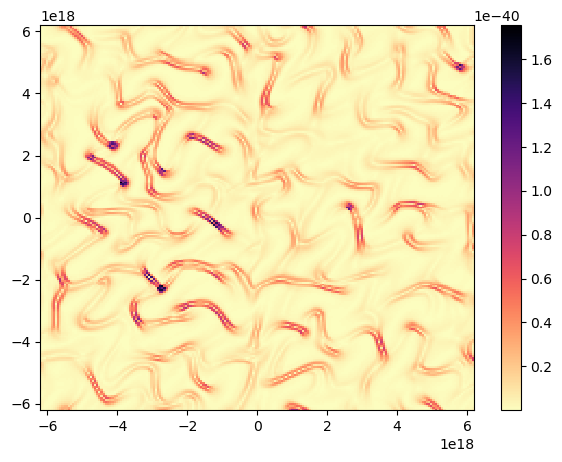

In [45]:
plt.figure(figsize = (7,5))

Z2 = plt.pcolor(X_hr, Y_hr, modulus_gradient_rho_hr, cmap = 'magma_r', shading = 'auto')#, clim = (0, 1.e-40), shading = 'auto')

CB2 = plt.colorbar(Z2)

plt.show()

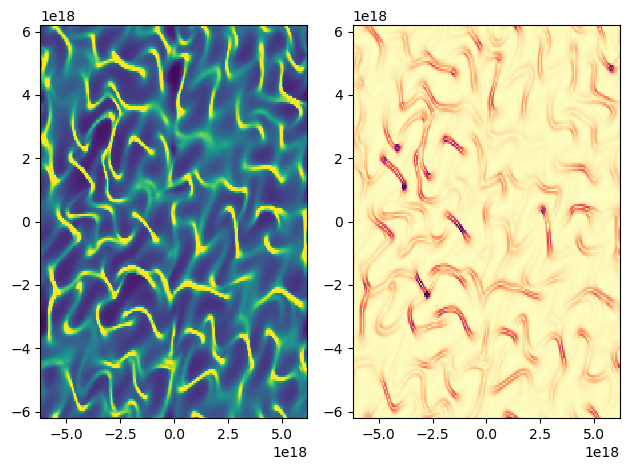

In [47]:
fig, axs = plt.subplots(1,2)

axs[0].pcolor(X_hr, Y_hr, rho_cgs2D_hr, cmap = 'viridis',\
              shading = 'auto', vmin = 0, vmax = 4.e-24)
axs[1].pcolor(X_hr, Y_hr, modulus_gradient_rho_hr, cmap = 'magma_r', shading = 'auto')#, clim = (0, 1.e-40), shading = 'auto')

fig.tight_layout()

### Edge detection:

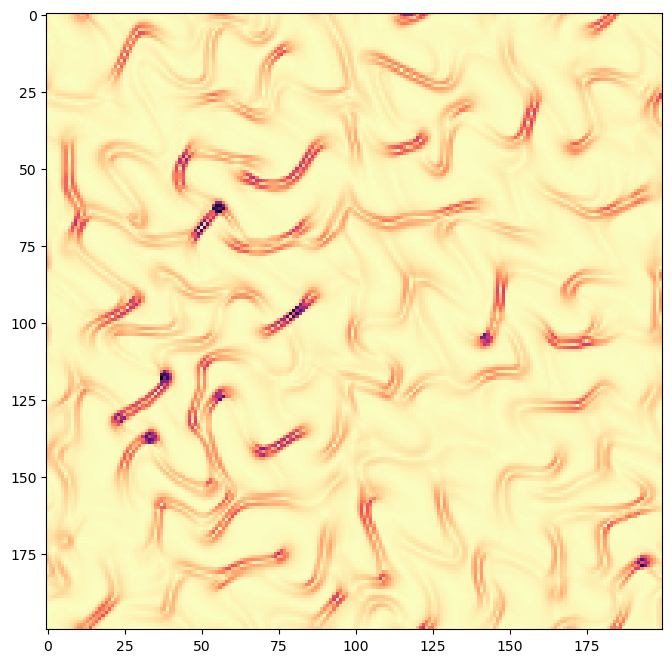

In [74]:
plt.figure(figsize=(10,8))

plt.imshow(modulus_gradient_rho_hr, cmap = 'magma_r')
plt.show()

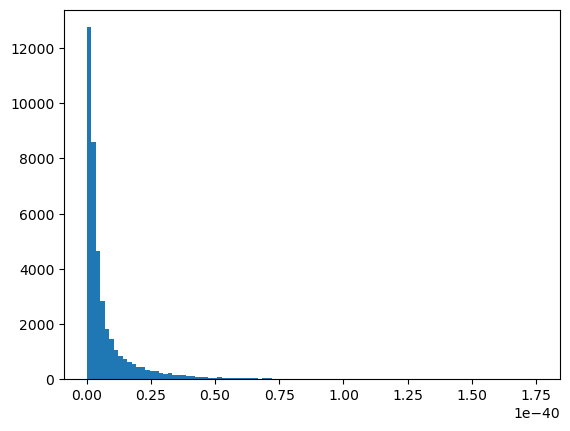

In [49]:
# Make a histogram
modulus_1d = modulus_gradient_rho_hr.flatten()

plt.figure()

plt.hist(modulus_1d, bins = 100)
plt.show()

In [76]:
print(np.min(modulus_1d), np.max(modulus_1d))

5.510846709523194e-45 1.7556361806717732e-40


In [50]:
# Isoolate the large gradients

modulus_1d_clean = np.where(modulus_1d > np.min(modulus_1d)*2.e3,1.,0.)

modulus_2d_clean = modulus_1d_clean.reshape(modulus_gradient_rho_hr.shape)

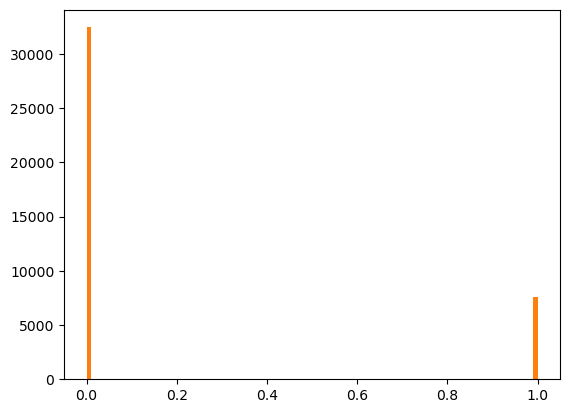

In [51]:
# Make a histogram
modulus_1d = modulus_gradient_rho_hr.flatten()

plt.figure()

plt.hist(modulus_1d, bins = 100)

plt.hist(modulus_1d_clean, bins = 100)
plt.show()

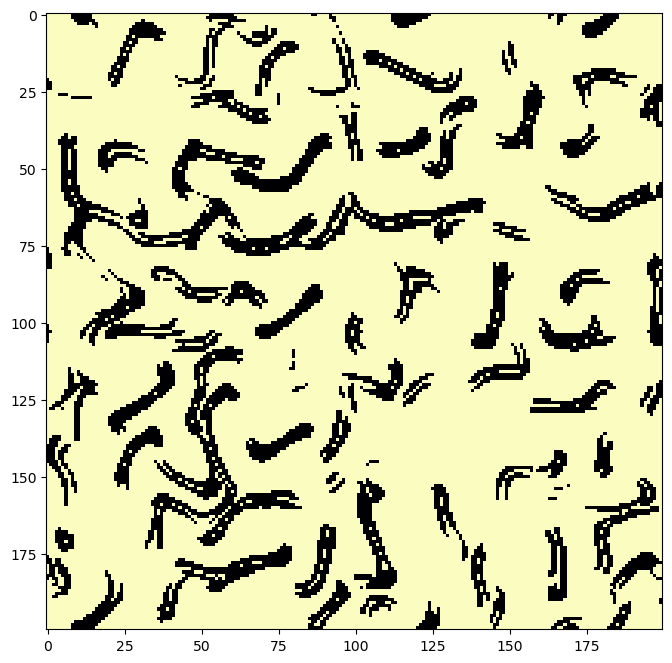

In [52]:
plt.figure(figsize=(10,8))

plt.imshow(modulus_2d_clean, cmap = 'magma_r')
plt.show()

We could find the area covered by the filamments or maybe check if they align in some direction.

## B. Curl of vector fields:

In [54]:
modulus_speed = np.sqrt(vx1_cgs2D**2 + vx2_cgs2D**2)

In [129]:
print(np.min(modulus_speed))
print(np.max(modulus_speed))


8038.680414262781
3234205.1495841267


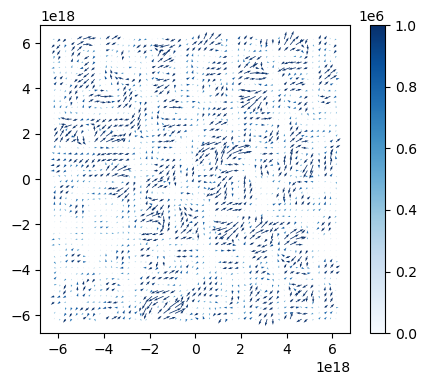

In [57]:
#Plot the velocity vector field, lr
plt.figure(figsize = (5,4))

Z = plt.quiver(X, Y, vx1_cgs2D, vx2_cgs2D, modulus_speed, cmap = 'Blues', clim = (0, 1.e6))#, angles='xy', scale_units='xy', scale=1)

CB = plt.colorbar(Z)

plt.show()

In [56]:
modulus_speed_hr = np.sqrt(vx1_cgs2D_hr**2 + vx2_cgs2D_hr**2)

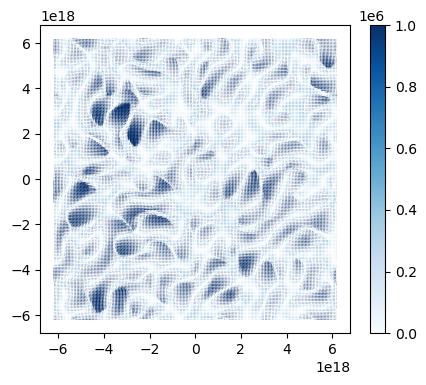

In [58]:
#Plot the velocity vector field, hr
plt.figure(figsize = (5,4))

Z = plt.quiver(X_hr, Y_hr, vx1_cgs2D_hr, vx2_cgs2D_hr, modulus_speed_hr, cmap = 'Blues', clim = (0, 1.e6))#, angles='xy', scale_units='xy', scale=1)

CB = plt.colorbar(Z)

plt.show()

# Curl:
The vorticity vector field is the curl of the velocity field. It indicates the formation of eddies.

In [60]:
def get_curl(comp1, comp2, dx):
    """
    Get curl of vector field.
    """
    curl1 = np.gradient(comp1, dx, axis = 0)
    curl2 = np.gradient(comp2, dx, axis = 1)
    curlt = curl2 - curl1 #recall the definition of curl in 2D
    return curlt

In [61]:
# Call function

curl_vel = get_curl(vx1_cgs2D, vx2_cgs2D, dx[0])

In [62]:
print(np.max(curl_vel))
print(np.min(curl_vel))

1.0861750139250661e-11
-1.0526912216862451e-11


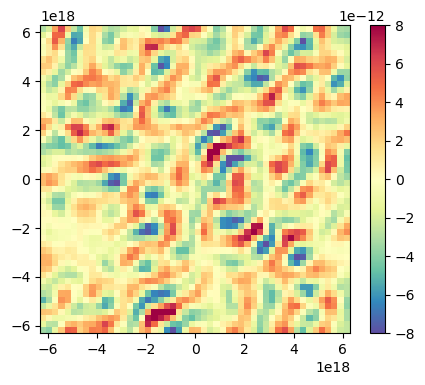

In [63]:
plt.figure(figsize = (5,4))

Z2 = plt.pcolor(X, Y, curl_vel, cmap = 'Spectral_r', shading = 'auto', vmin = -8e-12, vmax = 8.e-12)

CB2 = plt.colorbar(Z2)

plt.show()

Shows the eddies, spinning anticlockwise (positive values) and clockwise (negative values).

In [65]:
xx = np.linspace(mesh_hr.bounds[0], mesh_hr.bounds[1], mesh_hr.dimensions[0] - 1)
yy = np.linspace(mesh_hr.bounds[2], mesh_hr.bounds[3], mesh_hr.dimensions[1] - 1)

dxx = xx[1] - xx[0]

print(dx, dxx)

print(xx.shape)

[2.51918367e+17] 0.0201005025125629
(200,)


In [66]:
curl_vel_hr = get_curl(vx1_cgs2D_hr, vx2_cgs2D_hr, dx[0])

In [67]:
print(np.max(curl_vel_hr))
print(np.min(curl_vel_hr))

5.802751123441631e-12
-5.9285754228055415e-12


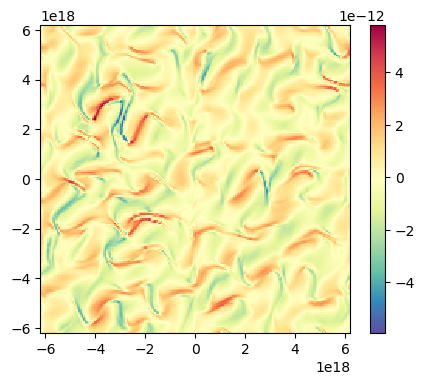

In [68]:
plt.figure(figsize = (5,4))

Z2 = plt.pcolor(X_hr, Y_hr, curl_vel_hr, cmap = 'Spectral_r', shading = 'auto')#, vmin = -8e7, vmax = 8.e7)

CB2 = plt.colorbar(Z2)

plt.show()

## C. Divergence of vector fields:


$$\vec{\nabla}\cdot \vec{B}= 0$$

It relates to the vector field dispersion.

In [69]:
# Magnitude of the magnetic field

modulus_bfield = np.sqrt(Bx1_cgs2D**2 + Bx2_cgs2D**2)

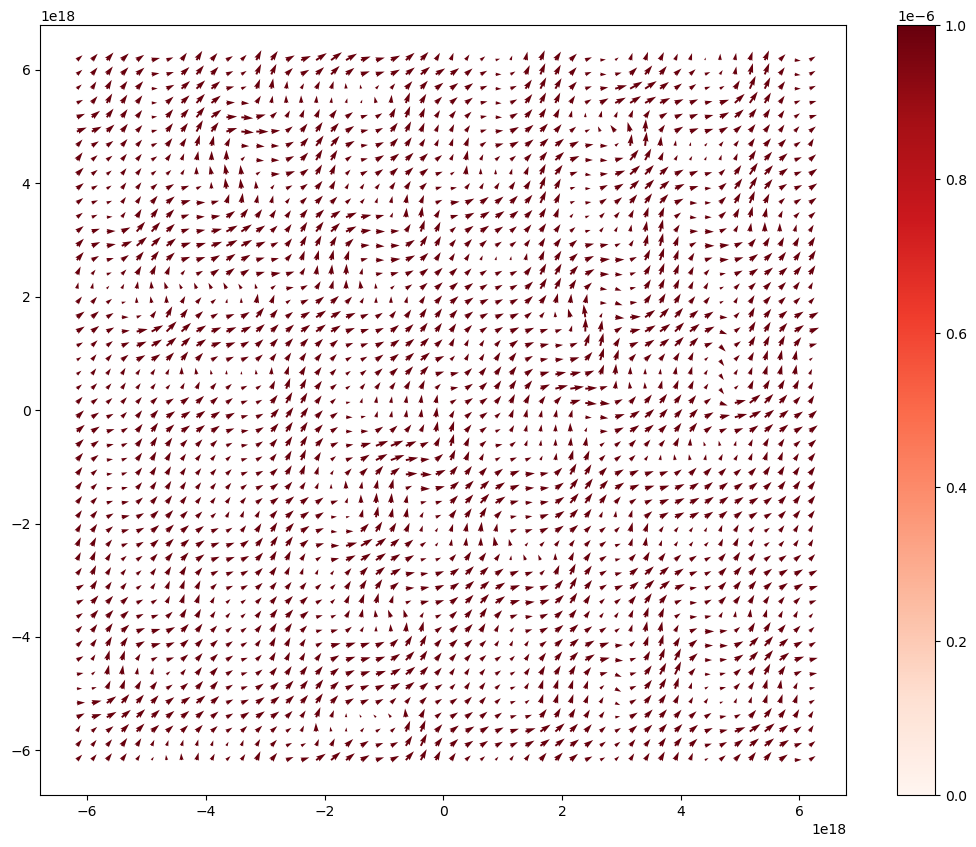

In [70]:
plt.figure(figsize = (13,10))

Z = plt.quiver(X, Y, Bx1_cgs2D, Bx2_cgs2D, modulus_bfield, cmap = 'Reds', clim = (0, 1.e-6))#, angles='xy', scale_units='xy', scale=1)

CB = plt.colorbar(Z)

plt.show()

In [81]:
def get_divergence(comp1, comp2, dx):
    
    """
    Function to get div of any vector.
    """
    
    div1 = np.gradient(comp1, dx[0], axis = 1) #axis in python are swapped
    div2 = np.gradient(comp2, dx[0], axis = 0)
    
    divt = div1 + div2 #recall the definition of divergence in 2D
    
    return divt

In [72]:
# Call our div function

div_bfield = get_divergence(Bx1_cgs2D, Bx2_cgs2D, dx)

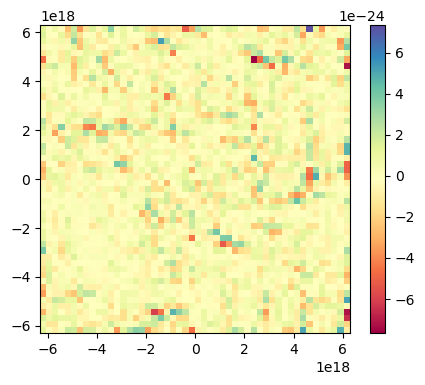

In [82]:
plt.figure(figsize = (5,4))

Z2 = plt.pcolor(X, Y, div_bfield, cmap = 'Spectral', shading = 'auto')#, vmin = -8e-5, vmax =8.e-5)

CB2 = plt.colorbar(Z2)

plt.show()

We have floating-point precission and order of accuracy (from calculating the derivatives) errors. Also, from using the gradient function.

Here, the errors are very very small compared to the order of the values. So, it's ok.

### High-resolution $B$

In [83]:
# Magnitude of the magnetic field

modulus_bfield_hr = np.sqrt(Bx1_cgs2D_hr**2 + Bx2_cgs2D_hr**2)

In [84]:
print(Bx1_cgs2D_hr.shape)

(200, 200)


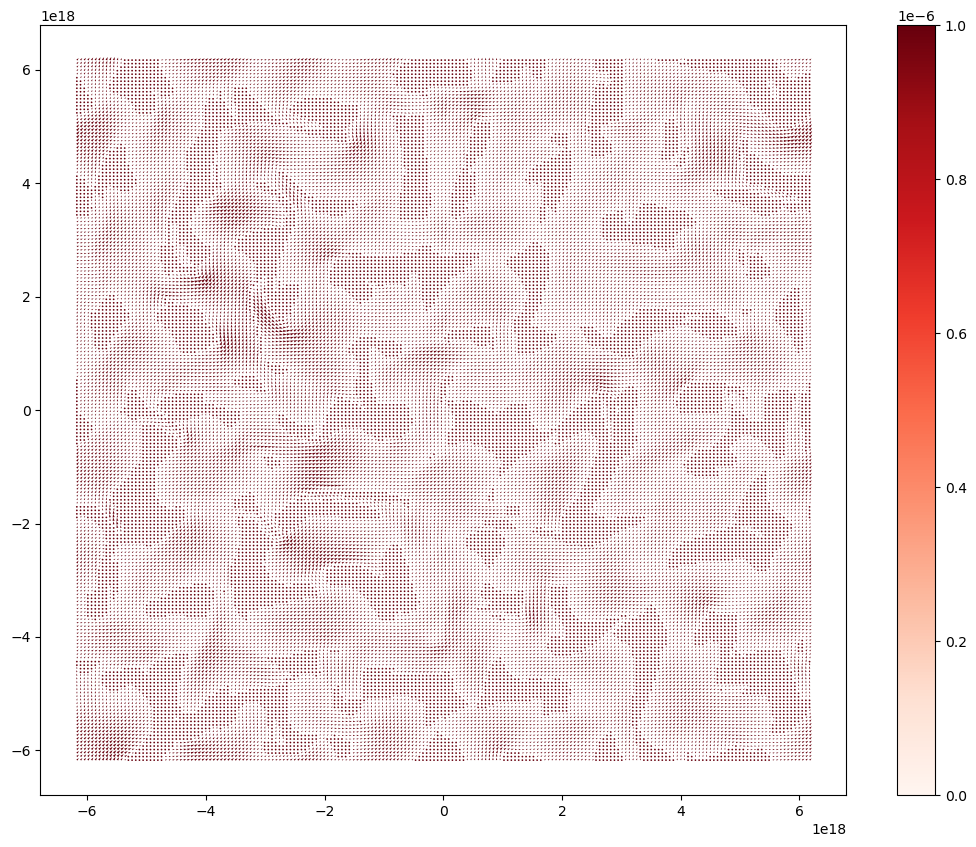

In [85]:
plt.figure(figsize = (13,10))

Z = plt.quiver(X_hr, Y_hr, Bx1_cgs2D_hr, Bx2_cgs2D_hr, modulus_bfield_hr, cmap = 'Reds', clim = (0, 1.e-6))#, angles='xy', scale_units='xy', scale=1)

CB = plt.colorbar(Z)

plt.show()

This should be re-scaled.

In [86]:
div_bfield_hr = get_divergence(Bx1_cgs2D_hr, Bx2_cgs2D_hr, dx)

In [87]:
print(np.max(div_bfield_hr))
print(np.min(div_bfield_hr))

5.720235904264762e-24
-6.61692458310579e-24


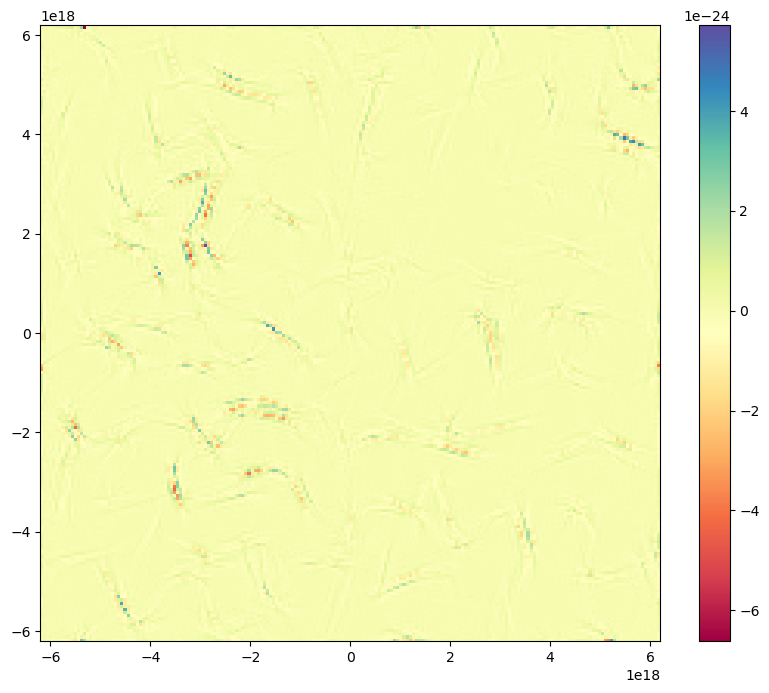

In [88]:
plt.figure(figsize = (10,8))

Z2 = plt.pcolor(X_hr, Y_hr, div_bfield_hr, cmap = 'Spectral', shading = 'auto')#, vmin = -8e-12, vmax = 8.e-12)

CB2 = plt.colorbar(Z2)

plt.show()

At high resolution, the divergence is closest for zero.

### 2nd option:

In [89]:
# Divergence function
def divergence(f,sp):
    num_dims = len(f)
    print(num_dims)
    #print(sp[0])
    return np.ufunc.reduce(np.add, [np.gradient(f[i], sp, axis=i) for i in range(num_dims)])


In [90]:
F = np.array([Bx2_cgs2D_hr, Bx1_cgs2D_hr])
sp_x = np.diff(xx)[0]

print(sp_x)

print(F[0])

0.0201005025125629
[[6.10250419e-06 6.51299783e-06 7.17685230e-06 ... 4.40498831e-06
  4.71294035e-06 4.96428012e-06]
 [6.20019626e-06 6.61003491e-06 7.20489165e-06 ... 4.55746188e-06
  4.94204857e-06 5.18220016e-06]
 [6.25286606e-06 6.70294168e-06 7.20065681e-06 ... 4.71929043e-06
  5.16814700e-06 5.39478826e-06]
 ...
 [5.48403787e-06 6.00702918e-06 6.76361401e-06 ... 4.01965979e-06
  3.90262128e-06 4.12368152e-06]
 [5.74322282e-06 6.21095541e-06 6.94049890e-06 ... 4.12504322e-06
  4.15264999e-06 4.43283029e-06]
 [5.95393905e-06 6.37781889e-06 7.06551216e-06 ... 4.26595755e-06
  4.43804217e-06 4.70881059e-06]]


In [91]:
div_bfield_hr2 = divergence(F, sp_x)

2


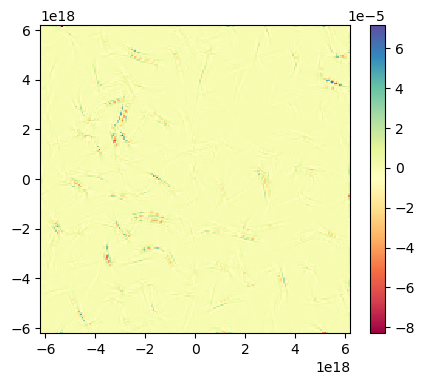

In [92]:
plt.figure(figsize = (5,4))

Z2 = plt.pcolor(X_hr, Y_hr, div_bfield_hr2, cmap = 'Spectral', shading = 'auto')#, vmin = -8e-12, vmax = 8.e-12)

CB2 = plt.colorbar(Z2)

plt.show()

### 3rd option:

In [93]:
def get_divergence2(comp1, comp2, x, y):
    diff_comp1 = np.diff(comp1,axis=1)[:-1,:]
    diff_x = np.diff(x,axis=1)[:-1,:]
    
    diff_comp2 = np.diff(comp2,axis=0)[:,:-1]
    diff_y = np.diff(y,axis=0)[:,:-1]    
    
    divt = diff_comp1/diff_x + diff_comp2/diff_y
    
    return divt

In [94]:
div_bfield2 = get_divergence2(Bx1_cgs2D, Bx2_cgs2D, X, Y)

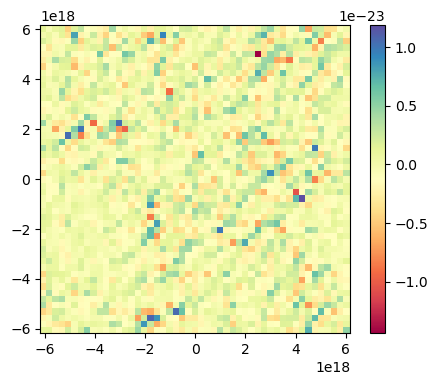

In [95]:
plt.figure(figsize = (5,4))

Z1 = plt.pcolor(X, Y, div_bfield2, cmap = 'Spectral', shading = 'auto')#, vmin = -1e-4, vmax= 1e-4)
#Z2 = plt.quiver(X, Y, x_gradient_rho, y_gradient_rho, total_gradient_rho, cmap = 'Oranges', clim = (0, 1.e-40))

CB1 = plt.colorbar(Z1)

#CB2 = plt.colorbar(Z2)

plt.show()

In [96]:
div_bfield2_hr = get_divergence2(Bx1_cgs2D_hr, Bx2_cgs2D_hr, X_hr, Y_hr)

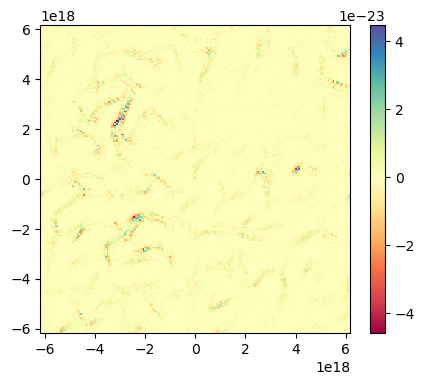

In [97]:
plt.figure(figsize = (5,4))

Z1 = plt.pcolor(X_hr, Y_hr, div_bfield2_hr, cmap = 'Spectral', shading = 'auto')#, vmin = -1e-4, vmax= 1e-4)
#Z2 = plt.quiver(X, Y, x_gradient_rho, y_gradient_rho, total_gradient_rho, cmap = 'Oranges', clim = (0, 1.e-40))

CB1 = plt.colorbar(Z1)

#CB2 = plt.colorbar(Z2)

plt.show()